<a href="https://colab.research.google.com/github/Vickytoreeya/Image-Recognition-with-Deep-Learning/blob/main/Tensor_Flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import baseline and Deep Learning libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score

print("TensorFlow version loaded successfully:", tf.__version__)

TensorFlow version loaded successfully: 2.20.0


Problem 1: Advertising Sales Prediction (Regression 1)
Business Scenario:
You are an advertising executive. You want to predict product Sales (in thousands of units) based on the budget spent on TV, Radio, and Newspaper advertisement channels (in thousands of dollars).

Dataset:
Run the code cell below to create the dataset as a Pandas DataFrame.



In [ ]:
# Create the advertising dataset
np.random.seed(42)
n_samples = 30
tv = np.random.uniform(10, 300, n_samples)
radio = np.random.uniform(5, 50, n_samples)
newspaper = np.random.uniform(2, 80, n_samples)

# true relation: sales = 10 + 0.05 * TV + 0.18 * Radio + 0.01 * Newspaper + Noise
sales = 10 + 0.05 * tv + 0.18 * radio + 0.01 * newspaper + np.random.normal(0, 2, n_samples)

df_adv = pd.DataFrame({'TV': tv, 'Radio': radio, 'Newspaper': newspaper, 'Sales': sales})
print("Dataset shape:", df_adv.shape)
display(df_adv.head())

Dataset shape: (30, 4)


,TV,Radio,Newspaper,Sales
0,118.616634,32.339518,32.316829,22.798385
1,285.707149,12.673586,23.165224,25.508016
2,222.278243,7.927322,66.641526,23.930037
3,183.610960,47.699849,29.826759,31.140862
4,55.245406,48.453441,23.912892,21.651367


Task 1.1: Split the Data
Split the dataset into features (X) and target (y). Then split them into training sets (80%) and testing sets (20%) using train_test_split with random_state=42.

In [ ]:
X_task = df_adv[['TV', 'Radio', 'Newspaper']]
y_task = df_adv['Sales']
print(X_task)

            TV      Radio  Newspaper
0   118.616634  32.339518  32.316829
1   285.707149  12.673586  23.165224
2   222.278243   7.927322  66.641526
3   183.610960  47.699849  29.826759
4    55.245406  48.453441  23.912892
5    55.238411  41.377881  44.330294
6    26.844248  18.707620  12.992090
7   261.191082   9.395245  64.571364
8   184.323353  35.790486   7.814950
9   215.341048  24.806862  78.977181
10   15.969503  10.491721  62.235092
11  291.273857  27.282961  17.499823
12  251.408366   6.547483   2.430725
13   71.578342  45.919418  65.605991
14   62.729240  16.645099  57.134873
15   63.187308  34.813503  58.862559
16   98.230250  19.026998  62.159087
17  162.179365  28.403061   7.775483
18  135.264055  29.601963  29.960327
19   94.456451  13.318450  11.037787
20  187.437339  48.631308  69.322067
21   50.453220  39.880977  50.617254
22   94.721948  47.277452  27.810046
23  116.244935  45.267231   6.957551
24  142.260295  31.905499  26.256621
25  237.701029  46.484341  27.364299
2

In [ ]:
# Task 1.1
# Split the dataset (80/20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_task, y_task, test_size=0.2, random_state=42)
#random_state=42 for reproducity i.e the ability to produce the same results
print(X_train_reg)

            TV      Radio  Newspaper
28  181.800225   7.035228  71.202594
24  142.260295  31.905499  26.256621
12  251.408366   6.547483   2.430725
0   118.616634  32.339518  32.316829
4    55.245406  48.453441  23.912892
16   98.230250  19.026998  62.159087
5    55.238411  41.377881  44.330294
13   71.578342  45.919418  65.605991
11  291.273857  27.282961  17.499823
22   94.721948  47.277452  27.810046
1   285.707149  12.673586  23.165224
2   222.278243   7.927322  66.641526
25  237.701029  46.484341  27.364299
3   183.610960  47.699849  29.826759
21   50.453220  39.880977  50.617254
26   67.905397   8.982163  58.909282
18  135.264055  29.601963  29.960327
29   23.470620  19.639865  38.832764
20  187.437339  48.631308  69.322067
7   261.191082   9.395245  64.571364
10   15.969503  10.491721  62.235092
14   62.729240  16.645099  57.134873
19   94.456451  13.318450  11.037787
6    26.844248  18.707620  12.992090


In [ ]:
# Task 1.2
# Instantiate a `StandardScaler`, fit it on the training features, and transform both training and test features.
scaler_task = StandardScaler()
X_train_scaled = scaler_task.fit_transform(X_train_reg)
X_test_scaled = scaler_task.transform(X_test_reg)
print(X_train_scaled[0])
print(X_test_scaled[0])

[ 0.55391544 -1.26567896  1.47018216]
[ 0.2913256  -0.82572839  0.53245661]


In [ ]:
# Task 1.3
# Build a Sequential Neural Network containing:
#1. A Dense input layer with 32 neurons, ReLU activation function, and the correct `input_shape`.
#2. A Dense hidden layer with 16 neurons and ReLU activation.
#3. A Dense output layer with 1 neuron (no activation function since this is regression).

#Print the model summary.

model_task = Sequential()
model_task.add(Dense(32, activation='relu', input_shape=(X_train_reg.shape[1],)))
model_task.add(Dense(16, activation='relu'))
model_task.add(Dense(1))

model_task.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673 (2.63 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
### Task 1.4: Compile and Train the Model
#Compile the model using the `adam` optimizer and `mean_squared_error` loss.
#Then train it for **50 epochs** with a `batch_size` of `4` and `validation_split=0.1`.

#loss function tells us how bad our error is
model_task.compile(optimizer='adam', loss='mean_squared_error')
print('model compiled successfully')

model compiled successfully


In [ ]:
history = model_task.fit(
    X_train_scaled,
    y_train_reg,
    epochs=90,
    batch_size=15,
    validation_split=0.1,
    verbose=1
)

Epoch 1/90
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 2.2794 - val_loss: 30.0390
Epoch 2/90
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 2.2734 - val_loss: 30.0116
Epoch 3/90
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 2.2663 - val_loss: 29.9947
Epoch 4/90
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 2.2610 - val_loss: 29.9647
Epoch 5/90
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 2.2549 - val_loss: 29.9442
Epoch 6/90
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 2.2489 - val_loss: 29.9204
Epoch 7/90
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 2.2421 - val_loss: 29.9087
Epoch 8/90
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 2.2376 - val_loss: 29.8857
Epoch 9/90
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 2.2299 - val_loss: 29.8952
Epoch 10/90
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 2.2248 - val_loss: 29.9080
Epoch 11/90
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 2.2200 - val_loss: 29.9164
Epoch 12/90
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 2.2128 - val

In [ ]:
### Task 1.5: Evaluate and Plot Predictions
#Make predictions on the test set, print the test Mean Squared Error (MSE), and create a scatter plot of Actual Sales vs. Predicted Sales with a diagonal dashed line.

In [ ]:
predicted = model_task.predict(X_test_scaled)
mse = mean_squared_error(y_test_reg, predicted)
print(mse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
2.4881973705924274


Text(0, 0.5, 'Predicted Ad Value')

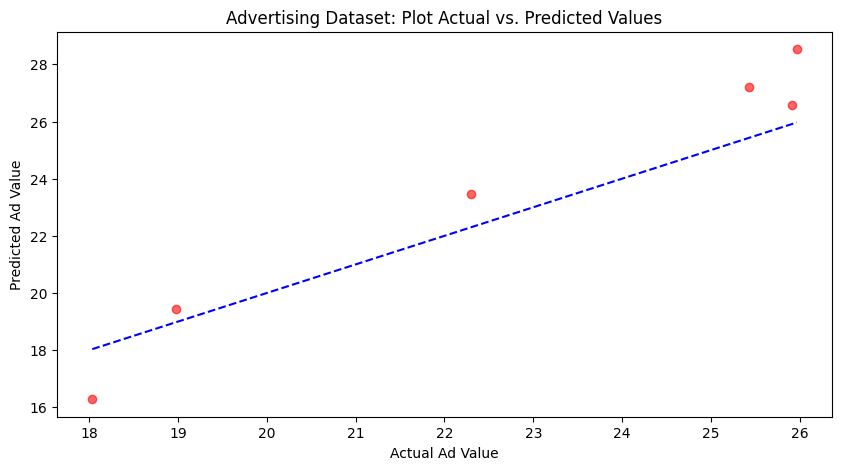

In [ ]:
# Visualization
plt.figure(figsize=(10,5))
plt.scatter(y_test_reg,predicted, alpha=0.6, color='red')
plt.plot([y_test_reg.min(), y_test_reg.max()],[y_test_reg.min(), y_test_reg.max()],'b--')
plt.title('Advertising Dataset: Plot Actual vs. Predicted Values')
plt.xlabel('Actual Ad Value')
plt.ylabel('Predicted Ad Value')


In [ ]:
# Create the wage dataset
np.random.seed(10)
n_wage_samples = 25
age = np.random.randint(22, 60, n_wage_samples)
education = np.random.choice([12, 16, 18, 20], n_wage_samples)
experience = age - education - 6
experience = np.clip(experience, 0, None)

# true relation: wage = 15 + 0.5 * Age + 2.0 * Education + 0.8 * Experience + Noise
wage = 15 + 0.5 * age + 2.0 * education + 0.8 * experience + np.random.normal(0, 3, n_wage_samples)

df_wage = pd.DataFrame({'Age': age, 'Education': education, 'Experience': experience, 'Wage': wage})
print("Dataset shape:", df_wage.shape)
display(df_wage.head())

Dataset shape: (25, 4)


,Age,Education,Experience,Wage
0,31,12,13,62.901094
1,58,18,34,106.167965
2,37,18,13,82.321156
3,22,18,0,68.425416
4,50,16,28,92.913145


### Task 2.1: Split and Scale the Data
1. Extract features (`Age`, `Education`, `Experience`) and target (`Wage`).
2. Split into 80% train and 20% test sets (`random_state=42`).
3. Scale features using `StandardScaler` (fit on train, transform both train and test)

In [ ]:
X_bus = df_wage[['Age', 'Education', 'Experience']]
y_bus = df_wage['Wage']
print(y_bus)

0      62.901094
1     106.167965
2      82.321156
3      68.425416
4      92.913145
5      87.276912
6      94.531061
7     103.311889
8      65.949077
9      67.958846
10     64.975691
11    109.453844
12     77.713245
13    101.412606
14     73.650869
15     90.841820
16    107.146830
17     63.084584
18    111.332974
19     66.975075
20     77.536365
21     62.455241
22     73.421908
23     95.589387
24     75.341720
Name: Wage, dtype: float64


In [ ]:
# Task 2.1
# Split the dataset (80/20%)
X_train_wage, X_test_wage, y_train_wage, y_test_wage = train_test_split(X_bus, y_bus, test_size=0.2, random_state=42)
#random_state=42 for reproducity i.e the ability to produce the same results
print(X_train_reg)

            TV      Radio  Newspaper
28  181.800225   7.035228  71.202594
24  142.260295  31.905499  26.256621
12  251.408366   6.547483   2.430725
0   118.616634  32.339518  32.316829
4    55.245406  48.453441  23.912892
16   98.230250  19.026998  62.159087
5    55.238411  41.377881  44.330294
13   71.578342  45.919418  65.605991
11  291.273857  27.282961  17.499823
22   94.721948  47.277452  27.810046
1   285.707149  12.673586  23.165224
2   222.278243   7.927322  66.641526
25  237.701029  46.484341  27.364299
3   183.610960  47.699849  29.826759
21   50.453220  39.880977  50.617254
26   67.905397   8.982163  58.909282
18  135.264055  29.601963  29.960327
29   23.470620  19.639865  38.832764
20  187.437339  48.631308  69.322067
7   261.191082   9.395245  64.571364
10   15.969503  10.491721  62.235092
14   62.729240  16.645099  57.134873
19   94.456451  13.318450  11.037787
6    26.844248  18.707620  12.992090


In [ ]:
# Task 1.2
# Instantiate a `StandardScaler`, fit it on the training features, and transform both training and test features.
scaler_wage = StandardScaler()
X_train_Scaler = scaler_wage.fit_transform(X_train_wage)
X_test_wage = scaler_wage.transform(X_test_wage)
print(X_train_Scaler[0])
print(X_test_wage[0])

[ 0.55391544 -1.26567896  1.47018216]
[ 0.2913256  -0.82572839  0.53245661]


In [ ]:
### Task 2.2: Build, Compile, and Train Model
#1. Build a Sequential network using `.add()` with one hidden Dense layer of 16 neurons (ReLU) and a single linear output layer (no activation).
#2. Compile with `adam` optimizer and `mean_squared_error` loss.
#3. Train for **100 epochs** with a batch size of `4` (`verbose=0` to keep output quiet).


In [ ]:

model_wage = Sequential()
model_wage.add(Dense(16, activation='relu', input_shape=(X_train_wage.shape[1],)))
model_wage.add(Dense(1))

model_wage.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_wage.compile(optimizer='adam', loss='mean_squared_error')
print('model compiled successfully')

model compiled successfully


In [ ]:
result = model_wage.fit(
    X_train_Scaler,
    y_train_wage,
    epochs=100,
    batch_size=4,
    validation_split=0.1,
    verbose=0
)


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 21
'y' sizes: 20
